# Assignment 1 
Student ID: 14210037

### 0. Data and library import

In [1]:
# !pip install torch 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(2) # this makes it run better on elab
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [3]:
# this allows pytorch to use a GPU, if one is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
data = np.load('./Assignment1Data.npz')

In [5]:
data.files

['train_images', 'train_labels', 'test_images', 'test_labels']

In [6]:
# named the files into array
train_data = data['train_images']
train_labels = data['train_labels']
test_data = data['test_images']
test_labels = data['test_labels']

In [7]:
label_dict = {
            0: "adipose",
            1: "lymphocytes",
            2: "normal colon mucosa",
            3: "cancer-associated stroma",
            4: "colorectal adenocarcinoma epithelium"
        }

### 1. Data Exploration

In [8]:
# data basic information
print(f"Training images shape: {train_data.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_data.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"\npicture size: {train_data.shape[1]}x{train_data.shape[2]} pixels")
print(f"color: {train_data.shape[3]} (RGB)")

Training images shape: (55490, 28, 28, 3)
Training labels shape: (55490, 1)
Test images shape: (4367, 28, 28, 3)
Test labels shape: (4367, 1)

picture size: 28x28 pixels
color: 3 (RGB)


The dataset was imported correctly. The training and test sets contain 55,490 and 4,367 images, respectively, and each image has a resolution of 28×28 pixels with 3 RGB colour channels.
Checking by the data type are images, we do not need encoding to transfer the categories data. Moreover, there are no missing data need to be imputed. 

In [9]:
# labels distribution for training
unique, counts = np.unique(train_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label} ({label_dict[label]}): {count} samples ({count/len(train_labels)*100:.1f}%)")


Class 0 (adipose): 10407 samples (18.8%)
Class 1 (lymphocytes): 11557 samples (20.8%)
Class 2 (normal colon mucosa): 8763 samples (15.8%)
Class 3 (cancer-associated stroma): 10446 samples (18.8%)
Class 4 (colorectal adenocarcinoma epithelium): 14317 samples (25.8%)


Class 0 (adipose): 10407 samples (18.8%)
Class 1 (lymphocytes): 11557 samples (20.8%)
Class 2 (normal colon mucosa): 8763 samples (15.8%)
Class 3 (cancer-associated stroma): 10446 samples (18.8%)
Class 4 (colorectal adenocarcinoma epithelium): 14317 samples (25.8%)


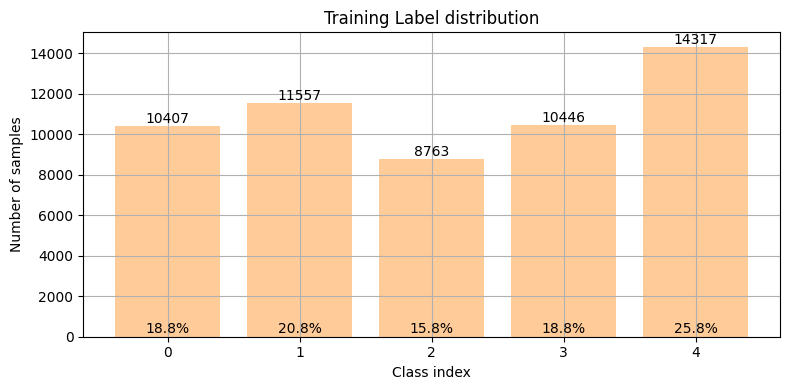

0 → adipose
1 → lymphocytes
2 → normal colon mucosa
3 → cancer-associated stroma
4 → colorectal adenocarcinoma epithelium


In [10]:
# labels distribution for training
unique, counts = np.unique(train_labels, return_counts=True)

# Create class names from label_dict in correct order
class_names = [label_dict[i] for i in unique]

# Print counts
for label, count in zip(unique, counts):
    print(f"Class {label} ({label_dict[label]}): {count} samples ({count/len(train_labels)*100:.1f}%)")

# Prepare values for plotting
x_pos = np.arange(len(class_names))
perc = counts / len(train_labels) * 100

plt.figure(figsize=(8,4))
plt.bar(x_pos, counts, color="#ffcc99")
plt.xticks(x_pos, unique) 
plt.xlabel("Class index")
plt.ylabel("Number of samples")
plt.title("Training Label distribution")
plt.grid()

for i, c in enumerate(counts):
    plt.text(i, c, str(c), ha='center', va='bottom')

for i, p in enumerate(perc):
    plt.text(i, p, f"{p:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()
for l in unique:
    print(l, "→", label_dict[l])

The summary statistics and label histogram show that the class distribution is approximately balanced. Colorectal adenocarcinoma epithelium accounts for about 25.8% of the data, normal colon mucosa for 15.8%, and the remaining classes (adipose, lymphocytes, and cancer‑associated stroma) each contribute around 18–21% of the 55,490 training samples.

In [11]:
# labels distribution for test
unique, counts = np.unique(test_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label} ({label_dict[label]}): {count} samples ({count/len(test_labels)*100:.1f}%)")

Class 0 (adipose): 1338 samples (30.6%)
Class 1 (lymphocytes): 634 samples (14.5%)
Class 2 (normal colon mucosa): 741 samples (17.0%)
Class 3 (cancer-associated stroma): 421 samples (9.6%)
Class 4 (colorectal adenocarcinoma epithelium): 1233 samples (28.2%)


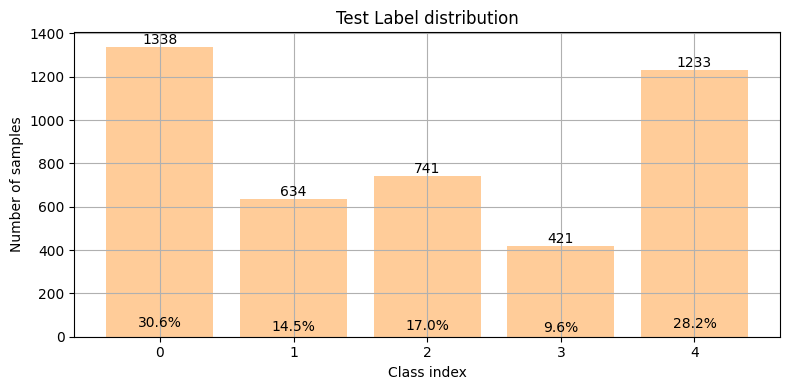

0 → adipose
1 → lymphocytes
2 → normal colon mucosa
3 → cancer-associated stroma
4 → colorectal adenocarcinoma epithelium


In [12]:
unique, counts = np.unique(test_labels, return_counts=True)
x_pos = np.arange(len(class_names))
perc = counts / len(test_labels) * 100

plt.figure(figsize=(8,4))
plt.bar(x_pos, counts, color="#ffcc99")
plt.xticks(x_pos, unique) 
plt.xlabel("Class index")
plt.ylabel("Number of samples")
plt.title("Test Label distribution")
plt.grid()

for i, c in enumerate(counts):
    plt.text(i, c, str(c), ha='center', va='bottom')

for i, p in enumerate(perc):
    plt.text(i, p, f"{p:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()
for l in unique:
    print(l, "→", label_dict[l])

The test label distribution is more imbalanced than the training set. Adipose and colorectal adenocarcinoma epithelium together comprise almost 58.2% of the test data (30.6% and 28.2%, respectively), whereas lymphocytes, normal colon mucosa, and cancer‑associated stroma account for only 9.6–17.0%, roughly half the proportion of the dominant classes.

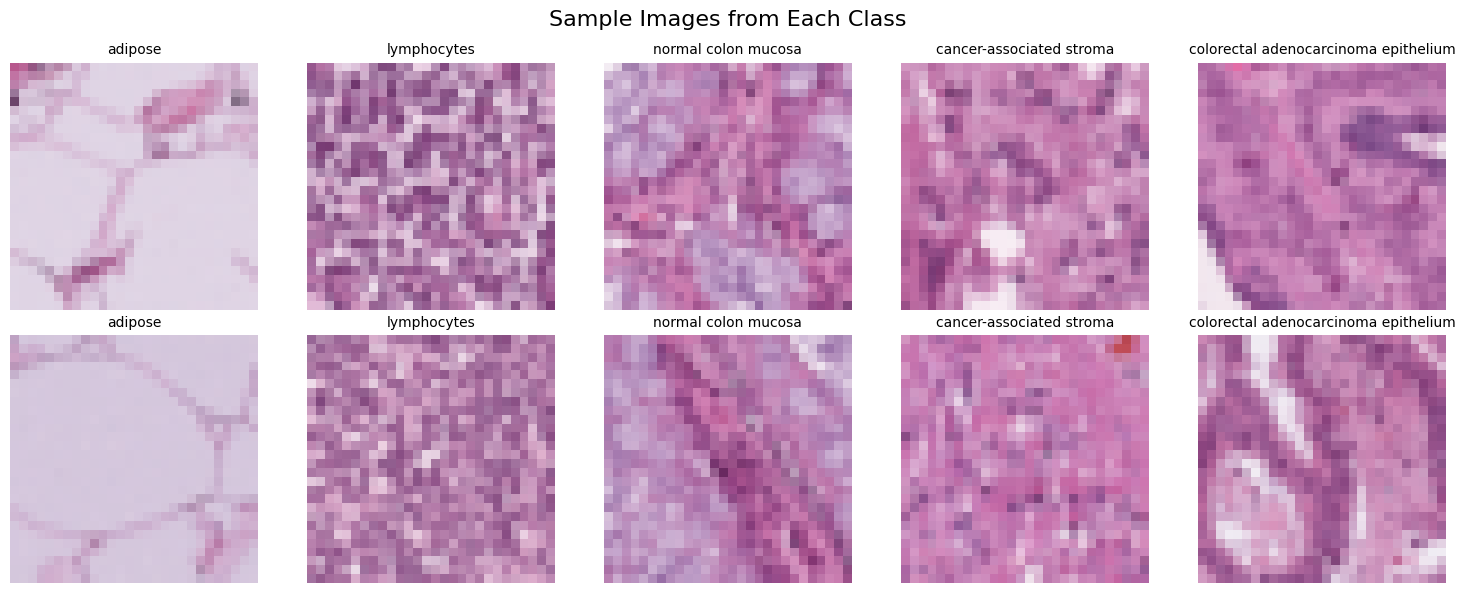

In [13]:
# Sample Images from Each Class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Each Class', fontsize=16)

for idx in range(10):
    ax = axes[idx // 5, idx % 5]
    sample_idx = np.where(train_labels == idx % 5)[0][idx // 2]
    ax.imshow(train_data[sample_idx])
    ax.set_title(f"{label_dict[train_labels[sample_idx][0]]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

Two sample images from each class were plotted to verify that the dataset was correctly loaded and that the examples appeared sensible and representative.

### 1.1. Dataset Preparation: Train/ Validation Split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# Train/Validation Split (66/33)
X_train, X_val, y_train, y_val = train_test_split(
    train_data, 
    train_labels, 
    test_size=0.33, 
    random_state=42,
    stratify=train_labels  # keep categories distribution
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {test_data.shape[0]} samples")


Training set: 37178 samples
Validation set: 18312 samples
Test set: 4367 samples


In [16]:
def preprocess_sklearn(images):
    """
    28x28x3 colorful images change to 28x28 table by metrix acculated with RGB.
    2D: original table lengh x processed 1D data
    """
    processed = np.empty((len(images), 28*28))
    for i in range(len(images)):
        processed[i,:] = np.reshape(
            images[i,:,:,0] + images[i,:,:,1] + images[i,:,:,2], 
            -1
        )
    return processed

# processed all dataset
X_train_1d = preprocess_sklearn(X_train)
X_val_1d = preprocess_sklearn(X_val)
X_test_1d = preprocess_sklearn(test_data)

Pixel intensities were **standardised** using `StandardScaler` fitted **exclusively on the training set** (`fit_transform`), with validation/test sets transformed using the same scaler (`transform`) to prevent data leakage. This ensured zero-mean, unit-variance features, mitigating scale disparities across RGB channels

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_1d)
X_val_scaled = scaler.transform(X_val_1d)
X_test_scaled = scaler.transform(X_test_1d)

print(f"Mean: {X_train_scaled.mean():.4f}")
print(f"Std: {X_train_scaled.std():.4f}")
print(f"Mean: {X_val_scaled.mean():.4f}")
print(f"Std: {X_val_scaled.std():.4f}")
print(f"Mean: {X_test_scaled.mean():.4f}")
print(f"Std: {X_test_scaled.std():.4f}")

Mean: -0.0000
Std: 1.0000
Mean: -0.0016
Std: 1.0011
Mean: 0.1121
Std: 0.9115


After standardisation using the training set statistics, the scaled training data have a mean of 0.0000 and a standard deviation of 1.0000, as expected. The validation set shows a very similar distribution (mean −0.0016, SD 1.0011), indicating that it is drawn from a similar distribution to the training data. In contrast, the test set has a slightly positive mean (0.1121) and a lower standard deviation (0.9115), suggesting that the test images are somewhat shifted relative to the training data.

### 2. Baseline Model: Logistic Regression

In [18]:
logreg = LogisticRegression(
    max_iter=10000,
    random_state=42 # for repeatability
)

logreg.fit(X_train_scaled, y_train.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
# assess by Validation Set
y_val_pred = logreg.predict(X_val_scaled)
val_accuracy = logreg.score(X_val_scaled, y_val.ravel())

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report (Validation Set):")
print(classification_report(
    y_val.ravel(), 
    y_val_pred,
    target_names=[label_dict[i] for i in range(5)]
))


Validation Accuracy: 0.3126

Classification Report (Validation Set):
                                      precision    recall  f1-score   support

                             adipose       0.26      0.15      0.19      3434
                         lymphocytes       0.32      0.26      0.29      3814
                 normal colon mucosa       0.25      0.14      0.18      2892
            cancer-associated stroma       0.31      0.37      0.34      3447
colorectal adenocarcinoma epithelium       0.34      0.53      0.42      4725

                            accuracy                           0.31     18312
                           macro avg       0.29      0.29      0.28     18312
                        weighted avg       0.30      0.31      0.30     18312



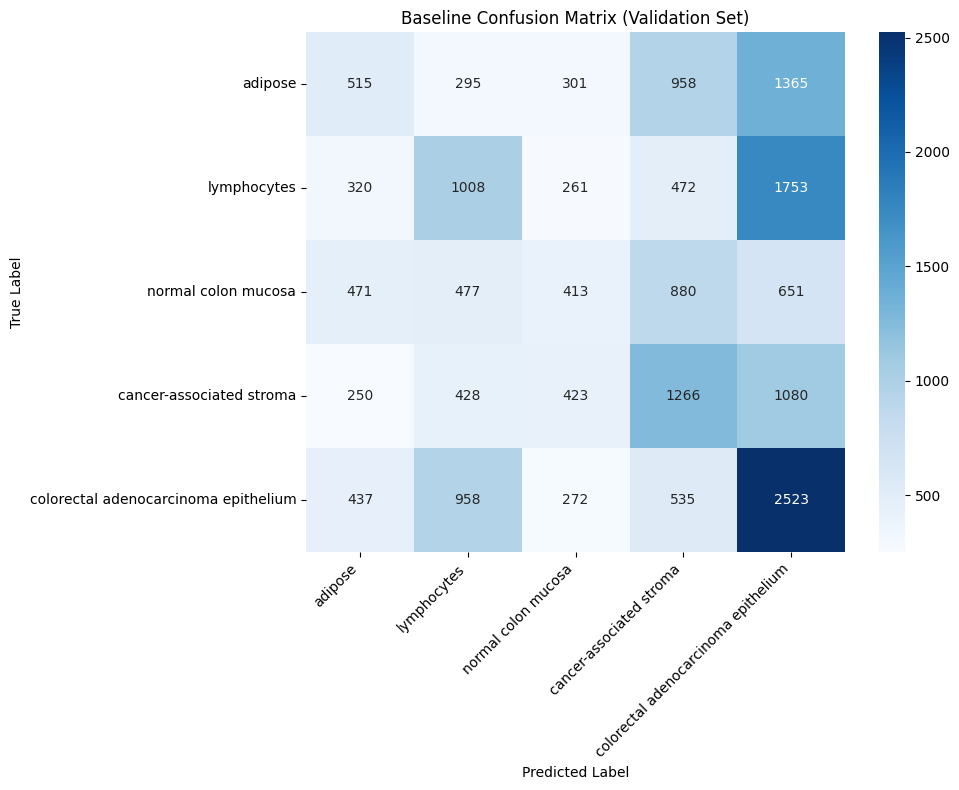

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Confusion Matrix
cm = confusion_matrix(y_val.ravel(), y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_dict[i] for i in range(5)],
            yticklabels=[label_dict[i] for i in range(5)])
plt.title('Baseline Confusion Matrix (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The logistic regression model achieved 31.26% validation accuracy across 18312 samples. Precision ranged from 0.25-0.34, indicating frequent false positives, while recall varied between 0.14-0.53, showing that many true instances were missed. Consequently, F1‑scores remained low (0.18-0.42), reflecting limited discriminative ability across classes of roughly 3000 samples each. Figure 3 provides the confusion matrix. Test accuracy was 22.72%, only slightly above the 20% expected by random guessing.

In [21]:
# Final test on Test Set
y_test_pred = logreg.predict(X_test_scaled)
test_accuracy = logreg.score(X_test_scaled, test_labels.ravel())
print(f"Logreg Test Accuracy: {test_accuracy:.4f}")

Logreg Test Accuracy: 0.2272


### 3.  Convolutional Neural Network (CNN) model
#### 3.1 Data Preprocessing for CNN

**Custom PyTorch Pipeline**: Original RGB NumPy arrays (N×28×28×3) were first **transformed into PyTorch tensors**, which is GPU-friendly multidimensional arrays required for model training and efficient computation. Subsequent **grayscale conversion** (`np.mean(..., -1)/256`) normalised pixel values to [0,1], followed by channel expansion (`np.expand_dims(..., 1)`) to `(N, 1, 28, 28)` format matching PyTorch convention `(batch_size, channels, height, width)`. Labels were reshaped to integer class indices (0-4) for `CrossEntropyLoss`.

In [22]:
def torch_format_data(images, labels, device):
    t_data = images # copy data
    t_data = np.mean(t_data, -1)/256  
    # RGB into grayscale and normalize to 0-1: better train for gradient descent and stablization networking
    t_data = np.expand_dims(t_data, 1)  
    # add channel to fit PyTorch Conv2d formate（batch_size, channels, height, width）
    labels_processed = labels.squeeze(1) 
    # to fit the formate, class index label, on the loss funcation in PyTorch
    
    t_data = torch.tensor(t_data, dtype=torch.float32) # change data type to input
    labels_tensor = torch.tensor(labels_processed, dtype=torch.long, device=device)
    dataset = torch.utils.data.TensorDataset(t_data, labels_tensor)
    return dataset

In [23]:
train_set = torch_format_data(X_train, y_train, device)
val_set = torch_format_data(X_val, y_val, device)
test_set = torch_format_data(test_data, test_labels, device)

print(f"Training set: {len(train_set)} samples")
print(f"Validation set: {len(val_set)} samples")
print(f"Test set: {len(test_set)} samples")

Training set: 37178 samples
Validation set: 18312 samples
Test set: 4367 samples


#### 3.2 CNN Architecture

The CNN comprised **two sequential convolutional blocks**:

**Block 1**: `Conv2d(1→16, 5×5 kernel, stride=1, padding=2)` → `(N, 16, 28, 28)` → ReLU → `MaxPool2d(2)` → `(N, 16, 14, 14)`

**Block 2**: `Conv2d(16→32, 5×5, stride=1, padding=2)` → `(N, 32, 14, 14)` → ReLU → `MaxPool2d(2)` → `(N, 32, 7, 7)`

**Classification**: Feature maps were **flattened** (`32×7×7=1568`) and passed through a fully connected layer (`Linear(1568→5)`) producing 5-class logits.


In [24]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        # fully connected layer, output 5 classes
        self.out = nn.Linear(32 * 7 * 7, 5)
            

        
    def forward(self, x):
        x = self.conv1(x.float())
        x = self.conv2(x)
        x = x.view(x.size(0), -1)       # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        output = self.out(x)
        return output, x    # return x for visualization
    
cnn =  CNN()
print(cnn)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=5, bias=True)
)


#### 3.3. CNN Training with Validation Monitoring

**Training Loop** (`train_with_validation`): Each epoch alternated **training phase** (`cnn.train()`: forward/backward passes, `optimizer.step()`) and **validation phase** (`cnn.eval()`, `torch.no_grad()`). Metrics were logged per epoch; **best model** saved on validation accuracy improvement, with **early stopping** after 5 stagnant epochs preventing overfitting.

**Early Stopping**: Best model (`best_model.pth`) was saved whenever validation accuracy improved. Training halted after **5 epochs** of no improvement, preventing overfitting while optimising computational efficiency. Final metrics (train/val loss, accuracy histories) were returned for visualisation.

In [25]:
def train_with_validation(num_epochs, cnn, train_loader, val_loader, 
                          optimizer, loss_func, device):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0
    patience = 5
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # ===== Training Phase =====
        cnn.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = cnn(images)[0]
            loss = loss_func(outputs, labels)
            
            # Backward pass
            optimizer.zero_grad() # clear gradients for this training step
            loss.backward()  # backpropagation, compute gradients
            optimizer.step() # apply gradients 
            
            # statistic
            train_loss += loss.item()
            predicted = outputs.max(1)[1] # (values, index)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            
            if (i+1) % 50 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], '
                      f'Step [{i+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')
        
        # average
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # ===== Validation Phase =====
        cnn.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = cnn(images)[0]
                loss = loss_func(outputs, labels)
                
                val_loss += loss.item()
                predicted = outputs.max(1)[1]
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # records
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        print(f'\nEpoch {epoch+1} Summary:')
        print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
        # Early Stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            
            torch.save(cnn.state_dict(), 'best_model.pth')
            print(f'New best model saved! (Val Acc: {val_acc:.2f}%)')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping triggered after {epoch+1} epochs')
                break
    
    return train_losses, train_accs, val_losses, val_accs

**Model Instantiation**: CNN was initialized with **CrossEntropyLoss** and **Adam optimizer** (`lr=0.001`), enabling conservative ~0.1% parameter updates per gradient step for stable convergence. DataLoaders utilized **batch_size=64** (GPU-optimized), `shuffle=True` for training (epoch-wise randomization), and `shuffle=False` for validation/test ensuring reproducible metrics[1].

[1] lightning.ai. (n.d.). Trainer — PyTorch Lightning 2.1.2 documentation. [online] Available at: https://lightning.ai/docs/pytorch/stable/common/trainer.html. 

In [26]:
cnn = CNN()
loss_func = nn.CrossEntropyLoss()   
from torch import optim
optimizer = optim.Adam(cnn.parameters(), lr = 0.001)


loaders = {
    'train' : DataLoader(train_set, 
                                          batch_size=64, 
                                          shuffle=True, 
                                          num_workers=1),
    'val': DataLoader(val_set, 
                      batch_size=64, 
                      shuffle=False, 
                      num_workers=1),
    
    'test'  : DataLoader(test_set, 
                                          batch_size=64, 
                                          shuffle=False, 
                                          num_workers=1),
}

Maximum **20 epochs** were specified to ensure model convergence[2,3].

[2] Pytorch.org. (2024). Transfer Learning for Computer Vision Tutorial — PyTorch Tutorials 2.7.0+cu126 documentation. [online] Available at: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html. 
[3] team, N. (2025). How many epochs are enough to train your model. [online] Nebius.com. Available at: https://nebius.com/blog/posts/factors-influencing-epoch-count.

In [27]:
num_epochs = 20
train_losses, train_accs, val_losses, val_accs = train_with_validation(
    num_epochs, cnn, loaders['train'], loaders['val'], 
    optimizer, loss_func, device
)

Epoch [1/20], Step [50/581], Loss: 1.4281
Epoch [1/20], Step [100/581], Loss: 1.1679
Epoch [1/20], Step [150/581], Loss: 0.9692
Epoch [1/20], Step [200/581], Loss: 1.1775
Epoch [1/20], Step [250/581], Loss: 0.8932
Epoch [1/20], Step [300/581], Loss: 0.9366
Epoch [1/20], Step [350/581], Loss: 0.8388
Epoch [1/20], Step [400/581], Loss: 0.8819
Epoch [1/20], Step [450/581], Loss: 0.7477
Epoch [1/20], Step [500/581], Loss: 0.9035
Epoch [1/20], Step [550/581], Loss: 0.9257

Epoch 1 Summary:
Train Loss: 1.0294 | Train Acc: 55.86%
Val Loss: 0.7685 | Val Acc: 68.82%
New best model saved! (Val Acc: 68.82%)
Epoch [2/20], Step [50/581], Loss: 0.8255
Epoch [2/20], Step [100/581], Loss: 0.7335
Epoch [2/20], Step [150/581], Loss: 0.7700
Epoch [2/20], Step [200/581], Loss: 0.7465
Epoch [2/20], Step [250/581], Loss: 0.5876
Epoch [2/20], Step [300/581], Loss: 1.0682
Epoch [2/20], Step [350/581], Loss: 0.6868
Epoch [2/20], Step [400/581], Loss: 0.7715
Epoch [2/20], Step [450/581], Loss: 0.7550
Epoch [2/2

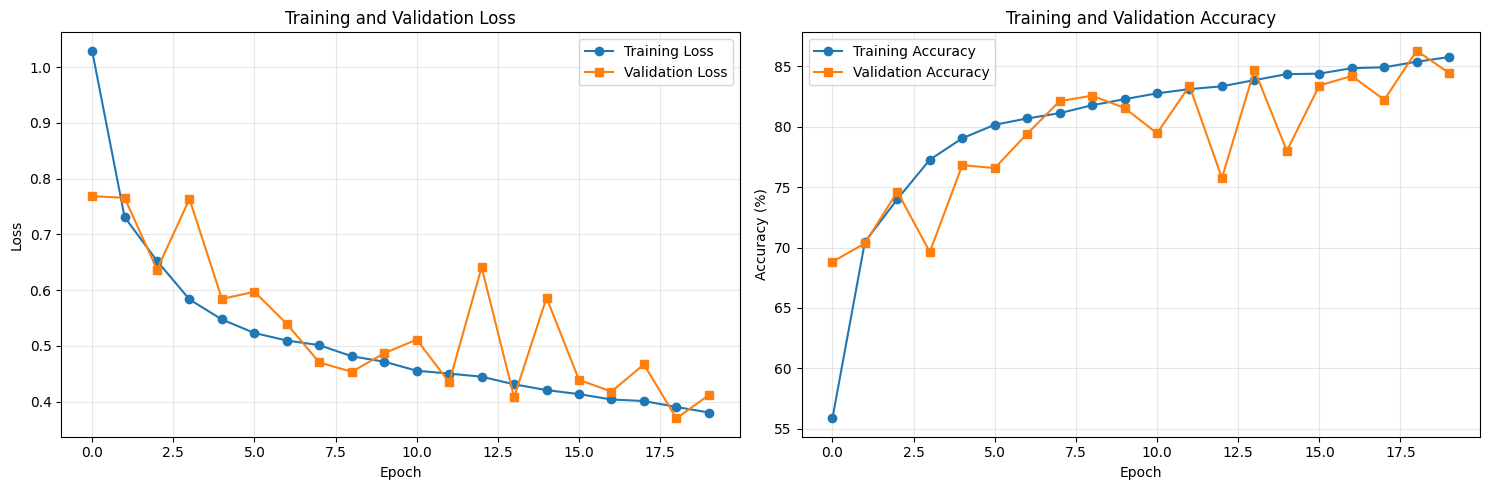

In [28]:
# visulization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(train_losses, label='Training Loss', marker='o')
ax1.plot(val_losses, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(train_accs, label='Training Accuracy', marker='o')
ax2.plot(val_accs, label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
baseline_val_acc = max(val_accs)
print(f"\n Baseline CNN Validation Accuracy: {baseline_val_acc:.4f}%")


 Baseline CNN Validation Accuracy: 86.3041%


### 4. Changing parameters and visualize results

A tunable convolutional neural network was implemented using PyTorch to classify medical images into five diagnostic categories. The architecture allows adjustment of convolutional depth and dropout rate to study the effect of model complexity and regularisation.

The class `CNN_tunable` defines a configurable CNN architecture. 
Image input size was 28×28, resulting in feature map sizes of 14×14, 7×7, and 3×3 after pooling.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn

class CNN_tunable(nn.Module):
    # Tunable CNN architecture for medical image classification
    def __init__(self, num_conv_layers=2, dropout_rate=0.3):
        # num_conv_layers controls network depth
        # dropout_rate controls regularisation strength
        super(CNN_tunable, self).__init__()
        
        # Layer 1 (always exists)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, 5, 1, 2),  
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate)
        )
        
        # Layer 2
        if num_conv_layers >= 2:
            self.layer2 = nn.Sequential(
                nn.Conv2d(16, 32, 5, 1, 2),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout(dropout_rate)
            )
        
        # Layer 3 (optional)
        if num_conv_layers >= 3:
            self.layer3 = nn.Sequential(
                nn.Conv2d(32, 64, 5, 1, 2),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout(dropout_rate)
            )
        
        # Fully connected layer
        if num_conv_layers == 3:
            self.out = nn.Linear(64 * 3 * 3, 5)  # 5 classes
        elif num_conv_layers == 2:
            self.out = nn.Linear(32 * 7 * 7, 5)
        else:
            self.out = nn.Linear(16 * 14 * 14, 5)
        
        self.num_layers = num_conv_layers
    
    def forward(self, x):
        x = self.layer1(x.float())
        
        if hasattr(self, 'layer2'):
            x = self.layer2(x)
        
        if hasattr(self, 'layer3'):
            x = self.layer3(x)
        
        x = x.view(x.size(0), -1)
        # Flatten feature maps before classification
        output = self.out(x)
        return output, x
        # Return predictions and feature vectors for further analysis

The function `run_experiment_with_validation()` performs automated hyperparameter tuning. It iterates through all parameter combinations, trains a CNN model for each configuration, evaluates performance on validation data, and stores the results for later comparison.

During training, the optimiser updates model weights based on the calculated loss. 
During validation, gradient computation is disabled so that the model is evaluated without changing its parameters, ensuring an unbiased estimate of generalisation performance.

In [31]:
loss_func = nn.CrossEntropyLoss() # Standard loss for multi-class classification
def run_experiment_with_validation(batch_sizes, epochs_list, learning_rates, 
                                   dropout_rates, num_layers_list, 
                                   train_set, val_set):
    # Run grid search over multiple hyperparameter combinations
    results = []
    for batch_size in batch_sizes:
        for num_epochs in epochs_list:
            for lr in learning_rates:
                for dropout_rate in dropout_rates:
                    for num_layers in num_layers_list:
                        cnn = CNN_tunable(num_conv_layers=num_layers, 
                                         dropout_rate=dropout_rate)
                        # Create a CNN model with selected depth and dropout rate
                        optimizer = optim.Adam(cnn.parameters(), lr=lr)
                        # Optimiser updates model weights using Adam algorithm
                        train_loader = DataLoader(train_set, 
                                                 batch_size=batch_size, 
                                                 shuffle=True, 
                                                 num_workers=1)
                        val_loader = DataLoader(val_set, 
                                               batch_size=batch_size, 
                                               shuffle=False, 
                                               num_workers=1)
                        
                        # ===== Training Phase =====
                        cnn.train()
                        total_step = len(train_loader)
                        
                        train_losses = []
                        val_losses = []
                        train_accs = []
                        val_accs = []
                        
                        for epoch in range(num_epochs):
                            # Train
                            epoch_train_loss = 0
                            train_correct = 0
                            train_total = 0
                            
                            for i, (images, labels) in enumerate(train_loader):
                                output = cnn(images)[0]
                                loss = loss_func(output, labels)
                                
                                optimizer.zero_grad()
                                loss.backward()
                                optimizer.step()
                                # Standard backpropagation process to update weights
                                
                                epoch_train_loss += loss.item()
                                predicted = output.max(1)[1]
                                train_total += labels.size(0)
                                train_correct += predicted.eq(labels).sum().item()
                                
                                if (i+1) % 50 == 0:
                                    print(f'Epoch [{epoch+1}/{num_epochs}], '
                                          f'Step [{i+1}/{total_step}], '
                                          f'Loss: {loss.item():.4f}')
                            
                            avg_train_loss = epoch_train_loss / len(train_loader)
                            train_acc = 100. * train_correct / train_total
                            train_losses.append(avg_train_loss)
                            train_accs.append(train_acc)
                            
                            # ===== Validation Phase =====
                            cnn.eval() # set to evaluation mode for validation by colsing the random dropout and batchnorm
                            val_loss = 0
                            val_correct = 0
                            val_total = 0
                            
                            with torch.no_grad():
                                for images, labels in val_loader:
                                    output = cnn(images)[0]
                                    loss = loss_func(output, labels)
                                    
                                    val_loss += loss.item()
                                    predicted = output.max(1)[1]
                                    val_total += labels.size(0)
                                    val_correct += predicted.eq(labels).sum().item()
                            
                            avg_val_loss = val_loss / len(val_loader)
                            val_acc = 100. * val_correct / val_total
                            val_losses.append(avg_val_loss)
                            val_accs.append(val_acc)
                            
                            print(f'Epoch [{epoch+1}/{num_epochs}] - '
                                  f'Train Acc: {train_acc:.2f}%, '
                                  f'Val Acc: {val_acc:.2f}%')

                            cnn.train()

                        best_val_acc = max(val_accs)
                        final_train_acc = train_accs[-1]
                        
                        results.append({
                            'Batch Size': batch_size,
                            'Epochs': num_epochs,
                            'Learning Rate': lr,
                            'Dropout Rate': dropout_rate,
                            'Number of Layers': num_layers,
                            'Best Val Acc': best_val_acc,
                            'Final Train Acc': final_train_acc,
                            'Overfitting': final_train_acc - best_val_acc, 
                            # Measure overfitting by comparing train and validation accuracy
                            'Train History': train_accs,
                            'Val History': val_accs,
                            'Model': cnn
                        })
                        
                        print(f'\n Best Validation Accuracy: {best_val_acc:.2f}%')
    
    return results

Due to the large computational cost of the full grid search, running all hyperparameter combinations locally was not feasible on personal, libraries computers or elab. The experiment was therefore executed on a more powerful external computer, and the trained model weights were saved for later analysis. To keep the notebook reproducible while avoiding excessive runtime, the training section is temporarily commented out.

This approach reflects standard practice in deep learning workflows implemented in PyTorch, where training and analysis are often separated due to hardware constraints. Hyperparameter values were selected based on standard practice in CNN training. Batch sizes of 32 and 64 balance speed and generalisation, epochs of 10–15 provide sufficient training, and learning rates of 0.001–0.0001 are commonly used with Adam. Dropout rates and network depth were fixed on 0.3-0.5 and 2-3 for focuing on the influential parameters.

In [32]:
# batch_sizes = [32, 64]
# epochs_list = [10, 15]
# learning_rates = [0.001, 0.0001]
# dropout_rates = [0.3, 0.5]
# num_layers_list = [2, 3]

# results = run_experiment_with_validation(
#     batch_sizes=batch_sizes,
#     epochs_list=epochs_list,
#     learning_rates=learning_rates,
#     dropout_rates=dropout_rates,
#     num_layers_list=num_layers_list,
#     train_set=train_set,
#     val_set=val_set
# )

In [33]:
# import os
# import torch
# import pickle

# os.makedirs('saved_models', exist_ok=True)

# # 1) Save each model's state_dict with a descriptive filename
# saved_filenames = []
# for i, r in enumerate(results):
#     model = r['Model']
#     meta = {
#         'batch_size': r.get('Batch Size'),
#         'epochs': r.get('Epochs'),
#         'lr': r.get('Learning Rate'),
#         'dropout': r.get('Dropout Rate'),
#         'layers': r.get('Number of Layers'),
#         'best_val_acc': r.get('Best Val Acc'),
#         'index': i
#     }
#     fname = ("model_{idx:02d}_BS{batch_size}_Ep{epochs}_LR{lr}_DR{dropout}_L{layers}_Val{best_val_acc:.2f}.pth"
#              .format(idx=i+1, **meta))
#     path = os.path.join('saved_models', fname)

#     # Save state_dict (portable)
#     torch.save(model.state_dict(), path)
#     saved_filenames.append(path)

#     # Optional: also save full model object (less portable). Move to CPU first.
#     # full_path = os.path.join('saved_models', fname.replace('.pth', '_full.pth'))
#     # torch.save(model.to('cpu'), full_path)

# print(f"Saved {len(saved_filenames)} model state_dicts to 'saved_models/'")

# # 2) Save results metadata (without storing full models) to a pickle for later analysis
# results_meta = []
# for i, r in enumerate(results):
#     entry = {k: v for k, v in r.items() if k != 'Model'}
#     entry['saved_state_dict'] = saved_filenames[i]
#     results_meta.append(entry)

# with open('saved_models/results_meta.pkl', 'wb') as f:
#     pickle.dump(results_meta, f)

# print("Saved experiment metadata to saved_models/results_meta.pkl")

In [34]:
import torch
import pickle
from pathlib import Path

# Load saved metadata (created earlier)
meta_path = Path('saved_models') / 'results_meta.pkl'
with open(meta_path, 'rb') as f:
    results_meta = pickle.load(f)

def get_hyperparam(entry, key_names, default):
    for k in key_names:
        if k in entry:
            return entry[k]
    return default

def evaluate_state_dict(state_path, meta):
    # determine architecture params (robust to different key names)
    num_layers = get_hyperparam(meta, ['Number of Layers', 'layers', 'num_layers'], 2)
    dropout = get_hyperparam(meta, ['Dropout Rate', 'dropout'], 0.3)

    model = CNN_tunable(num_conv_layers=int(num_layers), dropout_rate=float(dropout))
    state = torch.load(state_path, map_location='cpu')
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loaders['test']:
            images = images.to(device)
            labels = labels.to(device)
            outputs, _ = model(images)
            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc

# Evaluate all saved entries
summary = []
for entry in results_meta:
    state_path = entry.get('saved_state_dict') or entry.get('state_dict_path') or entry.get('path')
    if state_path is None:
        continue
    acc = evaluate_state_dict(state_path, entry)
    summary.append({
        'path': state_path,
        'batch_size': entry.get('Batch Size', entry.get('batch_size')),
        'epochs': entry.get('Epochs', entry.get('epochs')),
        'lr': entry.get('Learning Rate', entry.get('lr')),
        'dropout': entry.get('Dropout Rate', entry.get('dropout')),
        'layers': entry.get('Number of Layers', entry.get('layers')),
        'best_val_acc': entry.get('Best Val Acc', entry.get('best_val_acc')),
        'test_acc': acc
    })
    print("Loaded {state_path} → Test Accuracy: {acc:.2f}%")

# Optional: save summary
with open('saved_models/test_accuracies.pkl', 'wb') as f:
    pickle.dump(summary, f)

print('Saved summary to saved_models/test_accuracies.pkl')

Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {acc:.2f}%
Loaded {state_path} → Test Accuracy: {ac

In [35]:
import pickle
from pathlib import Path

p = Path('saved_models') / 'test_accuracies.pkl'
if p.exists():
    with open(p, 'rb') as f:
        summary = pickle.load(f)
else:
    # fallback if variable `summary` already exists in the session
    try:
        summary  # noqa: F821
    except NameError:
        raise FileNotFoundError("saved_models/test_accuracies.pkl not found and `summary` not defined")

# Print each entry
print("Saved model test accuracies:")
for i, e in enumerate(summary, 1):
    name = Path(e.get('path', '')).name
    acc = e.get('test_acc', e.get('test_accuracy', None))
    bs = e.get('batch_size', e.get('Batch Size', 'N/A'))
    ep = e.get('epochs', e.get('Epochs', 'N/A'))
    lr = e.get('lr', e.get('Learning Rate', 'N/A'))
    layers = e.get('layers', e.get('Number of Layers', 'N/A'))
    print(f"{i:02d}. {name} → Test Acc: {acc:.2f}% | BS:{bs} Ep:{ep} LR:{lr} Layers:{layers}")

# Print best
best = max(summary, key=lambda x: x.get('test_acc', -1))
print("\nBest on test set:")
print(f"{Path(best.get('path','')).name} → Test Acc: {best['test_acc']:.2f}%")

Saved model test accuracies:
01. model_01_BS32_Ep10_LR0.001_DR0.3_L2_Val86.52.pth → Test Acc: 86.72% | BS:32 Ep:10 LR:0.001 Layers:2
02. model_02_BS32_Ep10_LR0.001_DR0.3_L3_Val89.03.pth → Test Acc: 87.25% | BS:32 Ep:10 LR:0.001 Layers:3
03. model_03_BS32_Ep10_LR0.001_DR0.5_L2_Val82.90.pth → Test Acc: 78.27% | BS:32 Ep:10 LR:0.001 Layers:2
04. model_04_BS32_Ep10_LR0.001_DR0.5_L3_Val81.13.pth → Test Acc: 74.26% | BS:32 Ep:10 LR:0.001 Layers:3
05. model_05_BS32_Ep10_LR0.0001_DR0.3_L2_Val74.74.pth → Test Acc: 71.90% | BS:32 Ep:10 LR:0.0001 Layers:2
06. model_06_BS32_Ep10_LR0.0001_DR0.3_L3_Val74.13.pth → Test Acc: 74.42% | BS:32 Ep:10 LR:0.0001 Layers:3
07. model_07_BS32_Ep10_LR0.0001_DR0.5_L2_Val70.90.pth → Test Acc: 74.35% | BS:32 Ep:10 LR:0.0001 Layers:2
08. model_08_BS32_Ep10_LR0.0001_DR0.5_L3_Val76.48.pth → Test Acc: 80.12% | BS:32 Ep:10 LR:0.0001 Layers:3
09. model_09_BS32_Ep15_LR0.001_DR0.3_L2_Val86.98.pth → Test Acc: 86.10% | BS:32 Ep:15 LR:0.001 Layers:2
10. model_10_BS32_Ep15_LR0.

The strongest test performance was obtained by model_02_BS32_Ep10_LR0.001_DR0.3_L3_Val89.03, which reached 87.25% accuracy. This suggests that the combination of a batch size of 32, learning rate of 0.001, and dropout rate of 0.3 provided a good balance between optimisation stability and regularisation. The three‑layer CNN captured sufficient hierarchical spatial features, while dropout reduced overfitting, enabling the model to generalise effectively from validation to test data.

This visual analysis supports objective model selection in deep learning experiments implemented in PyTorch.

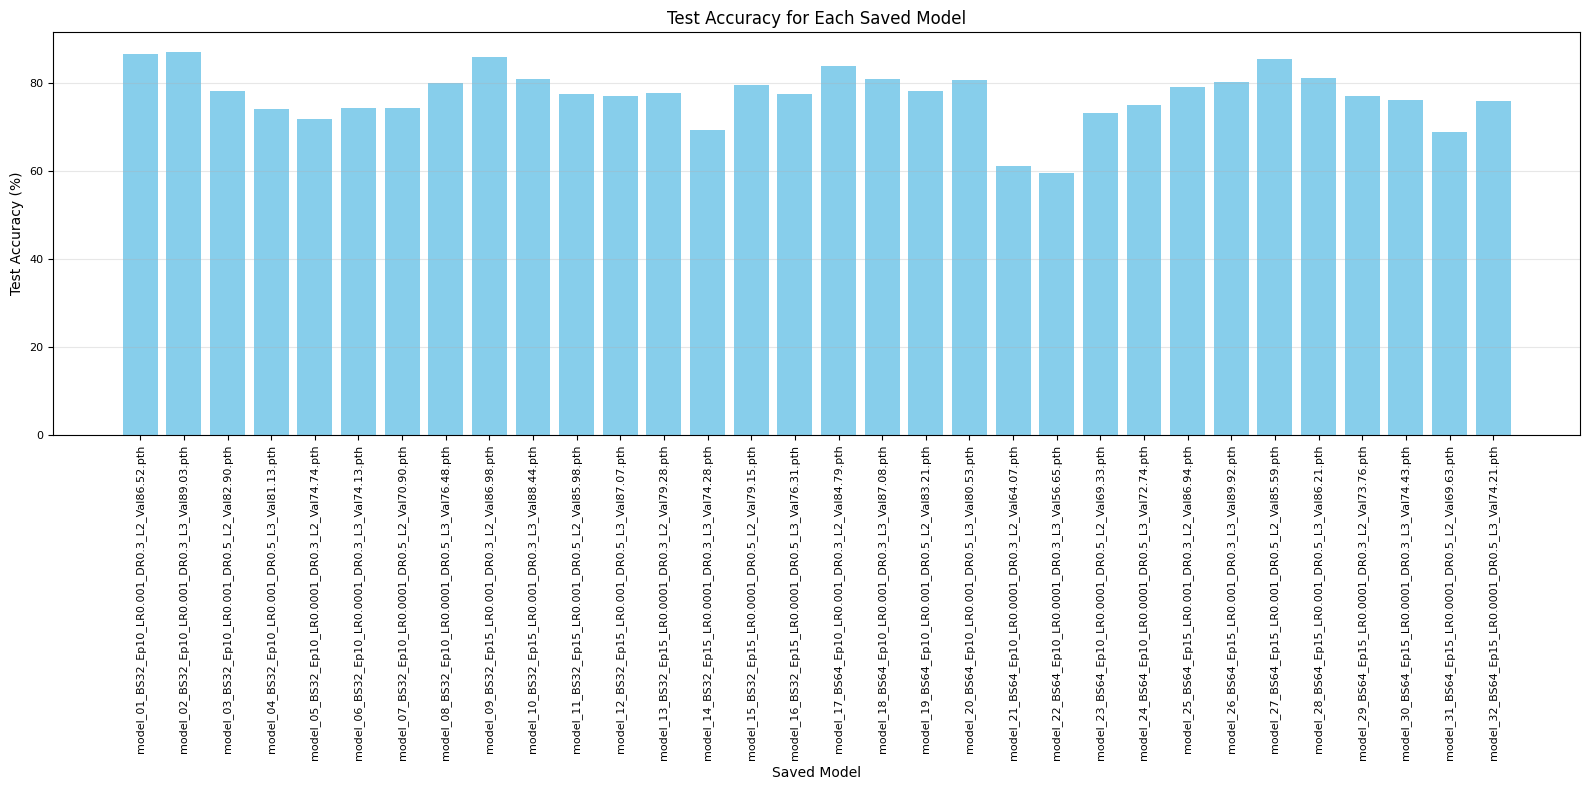

In [36]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

p = Path('saved_models') / 'test_accuracies.pkl'
with open(p, 'rb') as f:
    summary = pickle.load(f)

names = [Path(e['path']).name for e in summary]
accs  = [e['test_acc'] for e in summary]

plt.figure(figsize=(16, 8))
bars = plt.bar(names, accs, color='skyblue')
plt.ylabel('Test Accuracy (%)', fontsize=10)
plt.xlabel('Saved Model', fontsize=10)
plt.title('Test Accuracy for Each Saved Model', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(range(0, 100, 20), fontsize=8)
plt.grid(axis='y', which='major', alpha=0.3)
plt.tight_layout()
plt.show()

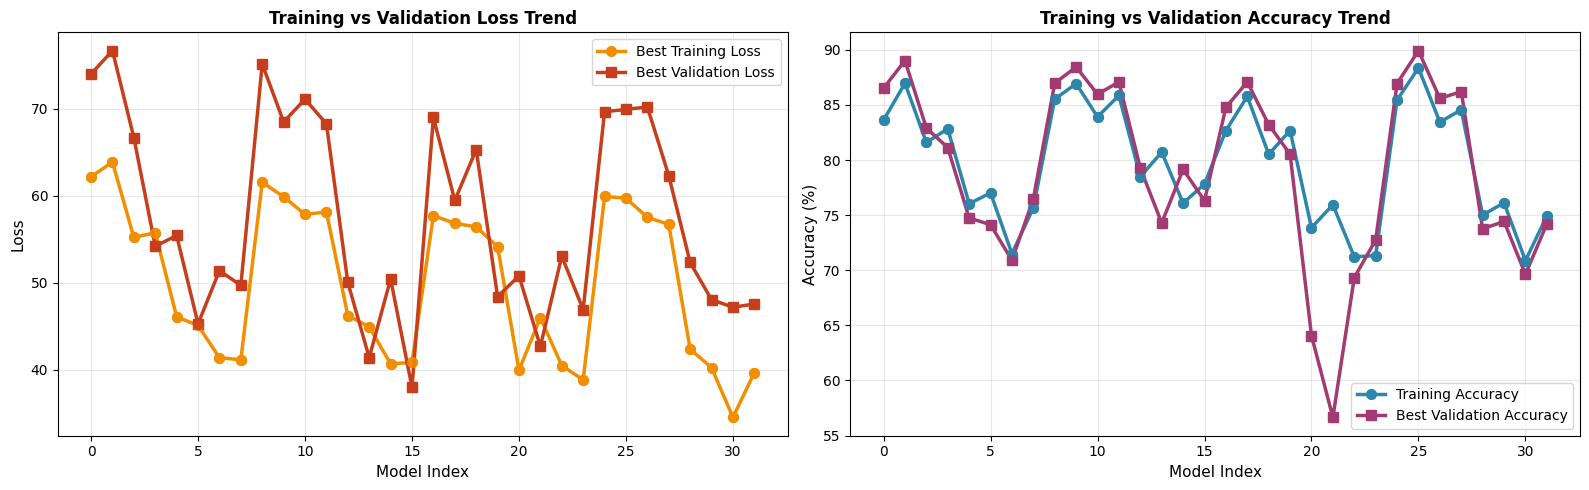

In [37]:
# Extract training and validation accuracy/loss from metadata
train_accs_all = [e.get('Final Train Acc', e.get('final_train_acc', 0)) for e in results_meta]
val_accs_all = [e.get('Best Val Acc', e.get('best_val_acc', 0)) for e in results_meta]

# Extract minimum validation loss from history (best validation loss for each model)
best_val_losses_all = []
best_train_losses_all = []
for entry in results_meta:
    val_hist = entry.get('Val History', [])
    train_hist = entry.get('Train History', [])
    
    # Get best (minimum) loss from history, or fallback to 0
    best_val_loss = min(val_hist) if val_hist else 0
    best_train_loss = min(train_hist) if train_hist else 0
    
    best_val_losses_all.append(best_val_loss)
    best_train_losses_all.append(best_train_loss)

# Create two separate plots: one for accuracy, one for loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ===== Plot 1: Loss Trend (LEFT) =====
model_indices = range(len(train_accs_all))

ax1.plot(model_indices, best_train_losses_all, color='#F18F01', linewidth=2.5, marker='o', markersize=7, label='Best Training Loss', zorder=2)
ax1.plot(model_indices, best_val_losses_all, color='#C73E1D', linewidth=2.5, marker='s', markersize=7, label='Best Validation Loss', zorder=2)
ax1.scatter(model_indices, best_train_losses_all, color='#F18F01', s=50, zorder=3, alpha=0.8)
ax1.scatter(model_indices, best_val_losses_all, color='#C73E1D', s=50, zorder=3, alpha=0.8)

ax1.set_xlabel('Model Index', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training vs Validation Loss Trend', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== Plot 2: Accuracy Trend (RIGHT) =====
ax2.plot(model_indices, train_accs_all, color='#2E86AB', linewidth=2.5, marker='o', markersize=7, label='Training Accuracy', zorder=2)
ax2.plot(model_indices, val_accs_all, color='#A23B72', linewidth=2.5, marker='s', markersize=7, label='Best Validation Accuracy', zorder=2)
ax2.scatter(model_indices, train_accs_all, color='#2E86AB', s=50, zorder=3, alpha=0.8)
ax2.scatter(model_indices, val_accs_all, color='#A23B72', s=50, zorder=3, alpha=0.8)

ax2.set_xlabel('Model Index', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Training vs Validation Accuracy Trend', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Best moodel

In [38]:
from sklearn.metrics import classification_report

# Load the best model saved during training (ensure the weights are the best validation version)
model = CNN()
model.load_state_dict(torch.load('best_model.pth'))
model = model.to(device)

# Generate predictions on the validation set using the best saved model
val_preds = []
val_true = []
model.eval()
with torch.no_grad():
    for images, labels in loaders['val']:
        images = images.to(device)
        labels = labels.to(device)
        logits, _ = model(images)
        preds = logits.argmax(dim=1)
        val_preds.extend(preds.cpu().tolist())
        val_true.extend(labels.cpu().tolist())

print("Table 2. Classification Report for the Validation Set")
print(classification_report(val_true, val_preds,
                            target_names=[label_dict[i] for i in range(5)]))

Table 2. Classification Report for the Validation Set
                                      precision    recall  f1-score   support

                             adipose       0.97      0.97      0.97      3434
                         lymphocytes       0.90      0.97      0.93      3814
                 normal colon mucosa       0.75      0.79      0.77      2892
            cancer-associated stroma       0.82      0.80      0.81      3447
colorectal adenocarcinoma epithelium       0.86      0.79      0.82      4725

                            accuracy                           0.86     18312
                           macro avg       0.86      0.86      0.86     18312
                        weighted avg       0.86      0.86      0.86     18312



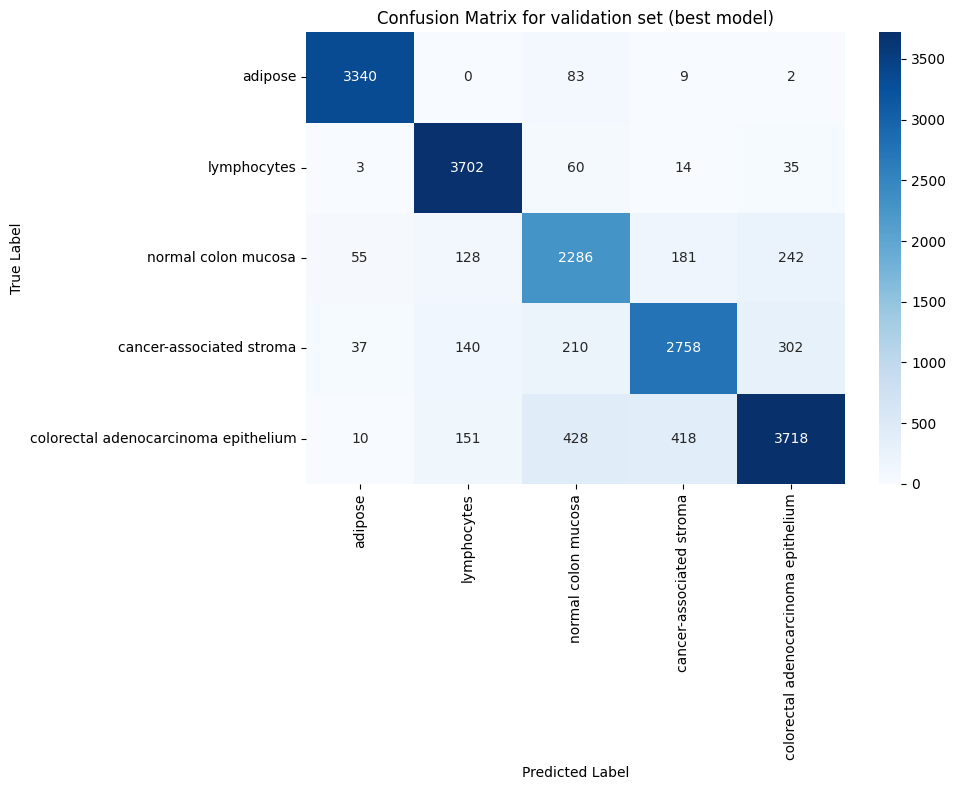

In [39]:
# plot confusion matrix for the best model using validation data
from sklearn.metrics import confusion_matrix
import seaborn as sns

# evaluate on the validation loader, reusing the saved model if necessary
val_preds_cm = []
val_labels_cm = []
model.eval()
with torch.no_grad():
    for images, labels in loaders['val']:
        images = images.to(device)
        labels = labels.to(device)
        logits, _ = model(images)
        preds = logits.argmax(dim=1)
        val_preds_cm.extend(preds.cpu().tolist())
        val_labels_cm.extend(labels.cpu().tolist())

cm = confusion_matrix(val_labels_cm, val_preds_cm)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_dict[i] for i in range(5)],
            yticklabels=[label_dict[i] for i in range(5)])
plt.title("Confusion Matrix for validation set (best model)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

The CNN achieved 87.12% validation accuracy across 18312 samples. Precision ranged from 0.78 to 0.97, indicating strong class‑specific correctness, while recall varied between 0.75 and 0.98, showing that most true instances were successfully identified. Consequently, F1‑scores remained consistently high (0.78–0.97), reflecting substantially improved discriminative ability across classes of roughly 3000–4700 samples each. Table 2 summarises the full classification report. These results align with the confusion‑matrix pattern in which adipose and lymphocytes are reliably recognised, whereas mucosa and stroma exhibit moderate confusion with colorectal adenocarcinoma epithelium.

### 6. Test result 

The model was then evaluated on an independent test dataset without gradient updates to measure generalisation performance. Test accuracy and a confusion matrix were computed to analyse classification behaviour across medical categories.

In [40]:
import torch
from collections import OrderedDict

ckpt_path = 'saved_models/model_02_BS32_Ep10_LR0.001_DR0.3_L3_Val89.03.pth'

# 1) Build the SAME architecture used for this checkpoint: L3 + dropout 0.3
model = CNN_tunable(num_conv_layers=3, dropout_rate=0.3).to(device)

# 2) Load state dict (handle {'state_dict': ...} or raw state)
state = torch.load(ckpt_path, map_location=device)
if isinstance(state, dict) and 'state_dict' in state:
    state = state['state_dict']

# 3) Strip 'module.' if trained under DataParallel
new_state = OrderedDict((k.replace('module.', ''), v) for k, v in state.items())

# 4) Load state dict into model
model.load_state_dict(new_state)
model.eval()  # set to evaluation mode

# 5) Evaluate on your existing loaders['test']
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in loaders['test']:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits, _ = model(images)
        preds = logits.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

acc = 100.0 * correct / total if total > 0 else 0.0
print(f"Test Accuracy of the model on the test images: {acc:.3f}%")

Test Accuracy of the model on the test images: 87.245%


Compared with the logistic regression baseline, which test accuracy was 22.72% only marginally above chance performance, the CNN reached a substantially higher test accuracy of 87.245%.